# Joint Modeling and Likelihood Analysis

In this notebook, we will use ```species``` and ```dynesty``` to load and sample atmospheric models, compute posterior distributions from a custom likelihood function, and plot best fitting results when jointly analyzing the continuum subtracted spectra alongside continuum-preserving datasets such as SPHERE or NIRCam.

### Initialization and Preparations

In [210]:
import os
import glob
from multiprocess import Pool

import numpy as np
import scipy
import matplotlib.pyplot as plt
import astropy.units as u
from astropy import constants as const

from breads.atm_utils import broadRGI
from breads.atm_utils import rprint
from breads.utils import filter_spec_with_spline
from breads.utils import get_err_from_posterior

import dynesty
from dynesty import NestedSampler
from dynesty import plotting as dyplot

from species.phot.syn_phot import SyntheticPhotometry

**This cell must be modified!** Specify the directory where you previously stored the data products. A new subdirectory is created for saving samples from the Nested Sampler.

In [211]:
base_path = '/astro/epsig/tutorial/'

save_dir = base_path+'samples/'
if not os.path.exists(save_dir):
    os.mkdir(save_dir)

Here we recover the list of targets from previously generated data products. For this demo we will only run on one example.

In [213]:
target_list = sorted([t.split('/')[-1].split('.')[0] for t in glob.glob(base_path+'products/*.npy')])
print(target_list)
target_list = target_list[-1:]
target_list

['HD 19467 1', 'HD 19467 2', 'HD 19467 3', 'HD 19467 J']


['HD 19467 J']

**WARNING!** This cell uses a large amount of resources. For sampler performance, we pre-compute the gaussian kernel broadening of the model atmosphere grid using the utility module ```breads.atm_utils.broadRGI``` once at R=2700 for the JWST/NIRSpec and once at R=100 for the ground-based low resolution spectra. Running this cell for the first time will take a long time (depending on the number of available cores). The results are saved in the same directory as the species config file so running it a second time should reload all of the precomputations. The atmosphere model also needs ~30 GB of disk space.

In [93]:
t2700 = broadRGI('sonora-elfowl-t',R=2700,preload=True)
t100 = broadRGI('sonora-elfowl-t',R=100,preload=True)

already exists, no preperations.
preloading...
done.
already exists, no preperations.
preloading...
done.


This cell uses a dictionary to create a mapping between target identifiers and the resulting ```broadRGI``` objects which is useful when iterating over multiple targets (perhaps one is t-type and the other is l-type and have different model objects).

In [214]:
bRGI_dict2700 = {'HD 19467 J':t2700}
bRGI_dict100 = {'HD 19467 J':t100}

Here we load the best fit radial velocities computed in notebook #3 during the CCF computation step. This allows us to define the model atmosphere prior uniformly in ```deltaRV``` in a narrower range of relevant velocities. For example if one of your targets had a velocity around 50 km/s it would make sense to limit the sampler to 50 +/- 15 km/s so we define the prior on deltaRV to be +/- 15 km/s.

In [216]:
best_RVs = np.load(base_path+'best_RVs.npy',allow_pickle=True).item()
best_RVs

{'HD 19467 J': 2000.0}

And the nodes are necessary again.

In [205]:
wv_nodes_dict = np.load(base_path+'nonuniform_nodes.npy',allow_pickle=True).item()
wv_nodes_dict['all'] = np.concatenate([wv_nodes_dict['nrs1'][:-1],wv_nodes_dict['nrs2'][1:]])

The following cell contains a collection of ground based spectroscopic and photometric data in a pair of nested python dictionaries with a particular structure. The dictionary keys are essentially:

```spectroscopic_archive['target']['Reference Year']['identifier']['wave' / 'spec' / 'err']```

```photometric_archive  ['target']['Reference Year']['filer_string']['flux' / 'err']```


These objects are iterated over when computing the likelihood and when plotting the results. The ```filter_string``` dictionary key has to map directly to the SVO filter profile identifier (https://svo2.cab.inta-csic.es/theory/fps/ so that ```species.phot.syn_phot.SyntheticPhotometry``` can compute bandpass specific flux integrals for those data, while the ```identifer``` dictionary key is just to give a name for the plot legend to different spectra that exist in the same journal reference.

In [206]:
spectroscopic_archive = {'HD 19467': {'Mesa 2020': {'SPHERE YJ': {'wave': np.array([0.970097, 0.971222, 0.972348, 0.973474, 0.9746  , 0.975726,       0.976852, 0.977978, 0.979105, 0.980232, 0.981358, 0.982485,       0.983612, 0.98474 , 0.985867, 0.986995, 0.988122, 0.98925 ,       0.990378, 0.991506, 0.992634, 0.993763, 0.994891, 0.99602 ,       0.997149, 0.998278, 0.999407, 1.00054 , 1.00167 , 1.00279 ,       1.00392 , 1.00505 , 1.00618 , 1.00731 , 1.00844 , 1.00957 ,       1.0107  , 1.01184 , 1.01297 , 1.0141  , 1.01523 , 1.01636 ,       1.01749 , 1.01862 , 1.01975 , 1.02088 , 1.02202 , 1.02315 ,       1.02428 , 1.02541 , 1.02654 , 1.02768 , 1.02881 , 1.02994 ,       1.03107 , 1.03221 , 1.03334 , 1.03447 , 1.03561 , 1.03674 ,       1.03787 , 1.03901 , 1.04014 , 1.04127 , 1.04241 , 1.04354 ,       1.04467 , 1.04581 , 1.04694 , 1.04808 , 1.04921 , 1.05035 ,       1.05148 , 1.05261 , 1.05375 , 1.05488 , 1.05602 , 1.05715 ,       1.05829 , 1.05942 , 1.06056 , 1.0617  , 1.06283 , 1.06397 ,       1.0651  , 1.06624 , 1.06737 , 1.06851 , 1.06965 , 1.07078 ,       1.07192 , 1.07306 , 1.07419 , 1.07533 , 1.07647 , 1.0776  ,       1.07874 , 1.07988 , 1.08101 , 1.08215 , 1.08329 , 1.08443 ,       1.08556 , 1.0867  , 1.08784 , 1.08898 , 1.09011 , 1.09125 ,       1.09239 , 1.09353 , 1.09467 , 1.0958  , 1.09694 , 1.09808 ,       1.09922 , 1.10036 , 1.1015  , 1.10263 , 1.10377 , 1.10491 ,       1.10605 , 1.10719 , 1.10833 , 1.10947 , 1.11061 , 1.11175 ,       1.11289 , 1.11403 , 1.11516 , 1.1163  , 1.11744 , 1.11858 ,       1.11972 , 1.12086 , 1.122   , 1.12314 , 1.12428 , 1.12542 ,       1.12656 , 1.1277  , 1.12884 , 1.12998 , 1.13112 , 1.13226 ,       1.1334  , 1.13454 , 1.13568 , 1.13682 , 1.13797 , 1.13911 ,       1.14025 , 1.14139 , 1.14253 , 1.14367 , 1.14481 , 1.14595 ,       1.14709 , 1.14823 , 1.14937 , 1.15052 , 1.15166 , 1.1528  ,       1.15394 , 1.15508 , 1.15622 , 1.15736 , 1.1585  , 1.15965 ,       1.16079 , 1.16193 , 1.16307 , 1.16421 , 1.16535 , 1.1665  ,       1.16764 , 1.16878 , 1.16992 , 1.17106 , 1.1722  , 1.17335 ,       1.17449 , 1.17563 , 1.17677 , 1.17791 , 1.17906 , 1.1802  ,       1.18134 , 1.18248 , 1.18363 , 1.18477 , 1.18591 , 1.18705 ,       1.18819 , 1.18934 , 1.19048 , 1.19162 , 1.19276 , 1.19391 ,       1.19505 , 1.19619 , 1.19733 , 1.19848 , 1.19962 , 1.20076 ,       1.2019  , 1.20305 , 1.20419 , 1.20533 , 1.20647 , 1.20762 ,       1.20876 , 1.2099  , 1.21104 , 1.21219 , 1.21333 , 1.21447 ,       1.21561 , 1.21676 , 1.2179  , 1.21904 , 1.22018 , 1.22133 ,       1.22247 , 1.22361 , 1.22475 , 1.2259  , 1.22704 , 1.22818 ,       1.22933 , 1.23047 , 1.23161 , 1.23275 , 1.2339  , 1.23504 ,       1.23618 , 1.23732 , 1.23847 , 1.23961 , 1.24075 , 1.24189 ,       1.24304 , 1.24418 , 1.24532 , 1.24646 , 1.24761 , 1.24875 ,       1.24989 , 1.25103 , 1.25218 , 1.25332 , 1.25446 , 1.2556  ,       1.25675 , 1.25789 , 1.25903 , 1.26017 , 1.26132 , 1.26246 ,       1.2636  , 1.26474 , 1.26589 , 1.26703 , 1.26817 , 1.26931 ,       1.27045 , 1.2716  , 1.27274 , 1.27388 , 1.27502 , 1.27616 ,       1.27731 , 1.27845 , 1.27959 , 1.28073 , 1.28187 , 1.28302 ,       1.28416 , 1.2853  , 1.28644 , 1.28758 , 1.28872 , 1.28987 ,       1.29101 , 1.29215 , 1.29329 , 1.29443 , 1.29557 , 1.29671 ,       1.29786 , 1.299   , 1.30014 , 1.30128 , 1.30242 , 1.30356 ,       1.3047  , 1.30584 , 1.30699 , 1.30813 , 1.30927 , 1.31041 ,       1.31155 , 1.31269 , 1.31383 , 1.31497 , 1.31611 , 1.31725 ,       1.31839 , 1.31953 , 1.32067 , 1.32181 , 1.32295 , 1.32409 ,       1.32523 , 1.32637 , 1.32751 , 1.32865 , 1.32979 , 1.33093 ,       1.33207 , 1.33321 , 1.33435 , 1.33549 , 1.33663 , 1.33777 ,       1.33891 ]), 'flux': np.array([ 4.15994e-17,  7.81304e-17,  4.29701e-17,  1.24970e-16,        2.08320e-17,  9.55939e-17,  6.48194e-17,  1.22450e-16,        1.24196e-16,  9.06878e-17,  8.23430e-17,  5.54854e-17,        7.88953e-17,  9.25722e-17,  8.81193e-17,  1.54719e-16,        1.32920e-16,  9.15695e-17,  6.21047e-17,  8.52151e-17,        1.22804e-16,  1.16254e-16,  1.45681e-16,  9.91229e-17,        1.29336e-16,  6.43788e-17,  8.73913e-17,  8.24501e-17,        1.20565e-16,  1.07268e-16,  1.23980e-16,  6.16592e-17,        6.52821e-17,  1.06646e-16,  1.10206e-16,  1.24648e-16,        1.14469e-16,  7.46227e-17,  8.95017e-17,  1.19981e-16,        9.11506e-17,  7.57016e-17,  1.17146e-16,  1.03904e-16,        8.08874e-17,  1.25840e-16,  1.00164e-16,  1.32573e-16,        1.06960e-16,  1.20312e-16,  1.21255e-16,  8.55273e-17,        9.64845e-17,  1.12267e-16,  1.36728e-16,  1.26547e-16,        1.56205e-16,  1.06980e-16,  1.07407e-16,  1.75698e-16,        1.71216e-16,  1.89678e-16,  1.97788e-16,  2.12916e-16,        2.02154e-16,  2.09171e-16,  1.69881e-16,  1.87391e-16,        2.34447e-16,  1.97905e-16,  2.36463e-16,  2.12692e-16,        2.37907e-16,  2.30803e-16,  2.55494e-16,  2.34668e-16,        2.84674e-16,  2.83917e-16,  2.26002e-16,  2.61521e-16,        2.42747e-16,  2.80901e-16,  2.78088e-16,  2.95939e-16,        2.92174e-16,  2.75463e-16,  2.72425e-16,  2.53967e-16,        2.95419e-16,  2.96139e-16,  3.01126e-16,  2.42099e-16,        2.96893e-16,  3.06642e-16,  2.91831e-16,  2.90233e-16,        2.75976e-16,  2.62057e-16,  2.44237e-16,  2.68710e-16,        2.61701e-16,  2.90056e-16,  2.75949e-16,  2.65184e-16,        2.48979e-16,  1.97536e-16,  2.30140e-16,  2.21753e-16,        1.71465e-16,  1.53295e-16,  1.45395e-16,  1.42060e-16,        1.20837e-16,  1.31019e-16,  1.08754e-16,  8.28207e-17,        8.97691e-17,  8.55106e-17,  5.89219e-17,  9.14207e-17,        8.48724e-17,  5.25122e-17,  4.73971e-17,  4.20248e-17,        4.66142e-17,  4.53303e-17,  7.02860e-17,  3.50300e-17,        6.55704e-17,  3.30372e-17,  9.11506e-17,  1.01378e-16,        2.00103e-17,  6.49886e-17,  7.45460e-17,  7.33481e-17,        7.50126e-17,  9.99019e-17,  8.89169e-17,  8.47961e-17,        1.03669e-16,  7.17998e-17,  3.72627e-17,  1.01430e-16,        1.26390e-17,  2.80401e-17,  2.74440e-17,  7.47302e-17,        7.91236e-17,  1.07057e-16,  7.29379e-17,  5.47363e-17,        6.45613e-17,  3.45950e-17,  2.26721e-17,  2.51231e-17,        1.29019e-16,  7.39083e-17,  9.30849e-17,  1.00387e-16,        6.17856e-17,  8.73652e-17,  8.33809e-17,  2.82513e-17,        5.10640e-17,  6.48720e-17,  3.45198e-17,  4.02976e-17,        3.75413e-17,  3.93731e-17,  4.39852e-17,  5.61922e-17,        6.09622e-17,  5.68329e-17,  4.09020e-17,  3.54738e-17,        6.87287e-17,  6.49512e-17,  7.62327e-17,  6.94141e-17,        6.50825e-17,  3.41077e-17,  6.64805e-17,  6.29456e-17,        5.63414e-17,  6.92036e-17,  6.28169e-17,  6.83096e-17,        9.53963e-17,  1.05265e-16,  6.38233e-17,  9.21252e-17,        8.00965e-17,  1.23935e-16,  7.97253e-17,  1.18427e-16,        1.14162e-16,  1.37965e-16,  1.31096e-16,  1.25352e-16,        1.15664e-16,  1.35295e-16,  1.29220e-16,  1.30147e-16,        1.09051e-16,  1.31286e-16,  1.72408e-16,  1.69264e-16,        2.06342e-16,  2.07711e-16,  1.63958e-16,  1.67212e-16,        1.84760e-16,  2.18164e-16,  2.06847e-16,  2.00095e-16,        2.56151e-16,  2.43979e-16,  2.24526e-16,  2.50087e-16,        2.39783e-16,  2.51593e-16,  2.61679e-16,  2.55333e-16,        2.97045e-16,  2.54530e-16,  2.84714e-16,  3.13302e-16,        3.16262e-16,  3.05102e-16,  3.04747e-16,  3.14202e-16,        2.85127e-16,  3.09139e-16,  3.06794e-16,  3.11068e-16,        2.79433e-16,  2.83013e-16,  2.85361e-16,  2.83260e-16,        2.84044e-16,  2.93768e-16,  2.99069e-16,  3.23796e-16,        3.09923e-16,  2.42051e-16,  2.90051e-16,  3.02685e-16,        2.69021e-16,  3.22629e-16,  3.39134e-16,  3.53821e-16,        3.62224e-16,  3.60899e-16,  3.78398e-16,  3.84079e-16,        3.82896e-16,  3.86446e-16,  3.56395e-16,  3.77345e-16,        3.86627e-16,  4.04386e-16,  3.86949e-16,  3.94421e-16,        3.87842e-16,  3.80197e-16,  3.93028e-16,  3.72953e-16,        3.81938e-16,  3.78461e-16,  3.79988e-16,  3.77207e-16,        3.86041e-16,  3.59665e-16,  3.59226e-16,  3.54804e-16,        3.84477e-16,  3.45104e-16,  3.51326e-16,  3.57692e-16,        3.59260e-16,  3.36784e-16,  3.47005e-16,  3.35646e-16,        3.27106e-16,  3.20758e-16,  2.94229e-16,  3.23127e-16,        3.08624e-16,  3.04815e-16,  2.96571e-16,  2.85129e-16,        2.80746e-16,  3.23794e-16,  2.85766e-16,  2.83991e-16,        3.26229e-16,  2.78027e-16,  2.71488e-16,  2.75567e-16,        2.61694e-16,  2.18010e-16,  2.41648e-16,  2.22610e-16,        2.41735e-16,  2.32726e-16,  2.31238e-16,  2.57098e-16,        2.14677e-16,  2.00575e-16,  1.73005e-16,  1.60559e-16,        1.46430e-16,  1.51820e-16,  1.08661e-16,  9.15008e-17,        6.26521e-17,  4.98837e-17,  3.14155e-17,  1.02852e-17,        1.41037e-17,  9.24166e-18, -9.97679e-18, -8.11961e-18,       -1.16118e-17]), 'err': np.array([1.44267e-17, 9.39796e-18, 3.60669e-18, 1.47583e-17, 1.18760e-17,       1.17012e-17, 7.85612e-18, 3.82812e-18, 1.91532e-17, 1.51791e-17,       8.49054e-18, 5.79668e-18, 1.45310e-17, 3.35901e-18, 2.40234e-17,       4.19186e-18, 1.12115e-17, 1.28660e-17, 5.42974e-18, 1.11606e-17,       1.04516e-17, 5.84383e-18, 8.09766e-18, 6.10112e-18, 9.03604e-18,       1.07862e-17, 9.94169e-18, 5.58080e-18, 3.48878e-18, 3.91421e-18,       1.14192e-17, 5.26872e-18, 6.29357e-18, 1.21772e-17, 1.01920e-18,       8.21162e-18, 4.14765e-18, 1.60815e-17, 7.20007e-18, 1.34185e-18,       1.18110e-17, 7.14245e-18, 1.07779e-17, 4.41279e-18, 8.15861e-18,       4.43453e-18, 5.23002e-18, 1.30679e-17, 1.18916e-17, 2.96916e-18,       9.63199e-18, 3.33058e-18, 1.30241e-17, 5.93663e-18, 7.47479e-18,       9.09227e-18, 8.70806e-18, 1.39018e-17, 5.94256e-18, 7.04995e-18,       2.51072e-18, 1.21052e-17, 5.66318e-18, 5.72106e-18, 3.32976e-18,       1.33958e-17, 5.89448e-18, 3.81994e-18, 1.07840e-17, 3.78818e-18,       5.22378e-18, 5.15047e-18, 6.03181e-18, 4.96580e-18, 3.76088e-18,       3.76793e-18, 1.06263e-17, 6.05299e-18, 4.54100e-19, 3.60675e-18,       2.18715e-18, 8.37280e-18, 6.82390e-19, 4.65019e-18, 4.30857e-18,       5.91176e-18, 1.13332e-17, 6.17646e-18, 6.45829e-18, 5.51416e-18,       6.03802e-18, 1.10623e-17, 5.96755e-18, 7.63685e-18, 3.24410e-18,       3.38191e-18, 1.04282e-17, 6.41567e-18, 8.67234e-18, 1.82138e-18,       7.41528e-18, 1.43143e-17, 7.49025e-18, 8.94327e-18, 6.04160e-19,       8.07832e-18, 1.99906e-18, 1.18686e-17, 8.58993e-18, 2.53134e-18,       2.65190e-18, 1.72844e-18, 2.37907e-18, 4.74630e-18, 4.60149e-18,       7.67083e-18, 5.61040e-18, 7.27818e-18, 7.20101e-18, 5.94922e-18,       1.32375e-17, 2.12971e-18, 3.57119e-18, 9.01909e-18, 1.28044e-17,       4.84731e-18, 2.34982e-18, 1.32140e-17, 1.62124e-17, 8.35441e-18,       5.52674e-18, 2.51730e-17, 4.22138e-17, 7.43246e-18, 1.54904e-17,       5.60788e-18, 2.10202e-17, 5.59712e-18, 1.40385e-17, 1.46702e-17,       3.55523e-18, 6.40283e-18, 7.26815e-18, 1.43657e-17, 4.97017e-18,       2.20105e-17, 4.72844e-18, 7.61385e-18, 1.53889e-17, 8.34610e-18,       7.39056e-18, 4.78946e-18, 3.83680e-18, 6.85180e-18, 9.83226e-18,       1.00697e-17, 8.82994e-18, 6.15610e-18, 2.49007e-18, 3.57766e-18,       3.70838e-18, 4.73696e-18, 8.99528e-18, 1.17506e-17, 2.24325e-18,       1.07617e-18, 7.33373e-18, 5.86627e-18, 5.94382e-18, 8.70624e-18,       2.40176e-18, 4.16986e-18, 4.67267e-18, 5.60158e-18, 7.34753e-18,       3.24877e-18, 2.68052e-18, 7.33543e-18, 1.03867e-17, 6.16063e-18,       4.49339e-18, 2.55891e-18, 5.20787e-18, 2.94653e-18, 5.30391e-18,       2.06687e-18, 4.66071e-18, 3.30953e-18, 5.02283e-18, 9.85399e-18,       3.46598e-18, 1.18086e-17, 3.76289e-18, 7.98900e-18, 4.69416e-19,       5.03172e-18, 5.62311e-18, 2.33653e-18, 1.53132e-18, 4.67283e-18,       4.95532e-18, 3.86552e-18, 1.72957e-18, 5.70526e-18, 5.28492e-18,       1.71497e-18, 7.38928e-18, 3.39120e-18, 6.20346e-18, 4.47830e-18,       5.94599e-19, 3.20522e-18, 4.65689e-18, 3.38597e-18, 5.44697e-18,       2.62566e-18, 3.80269e-18, 4.16880e-18, 2.35483e-18, 5.97330e-18,       4.19200e-18, 5.45026e-18, 5.54980e-18, 3.93297e-18, 5.63215e-18,       2.58568e-18, 5.02349e-18, 8.28704e-18, 5.14759e-18, 8.71064e-18,       8.13762e-18, 1.16380e-17, 5.79699e-18, 6.59459e-18, 7.49810e-18,       3.45554e-18, 6.65329e-18, 6.87768e-18, 9.21573e-18, 1.13134e-17,       8.01668e-18, 3.21134e-18, 9.78585e-18, 5.87517e-18, 4.37153e-18,       4.92468e-18, 1.75007e-18, 4.42483e-18, 7.59931e-18, 5.27330e-18,       1.36363e-18, 8.11199e-18, 6.19202e-18, 2.95930e-18, 4.48666e-18,       1.66229e-18, 3.30817e-18, 4.51057e-18, 5.58100e-18, 2.35060e-19,       2.94611e-18, 6.22547e-18, 2.25981e-18, 5.31818e-18, 6.21490e-18,       9.27572e-18, 1.28441e-18, 2.41657e-18, 2.61607e-18, 4.62718e-18,       4.96919e-18, 3.12723e-18, 3.44868e-18, 3.84819e-18, 4.64681e-18,       5.64614e-18, 5.11441e-18, 6.61298e-18, 3.10747e-18, 7.48106e-18,       9.18616e-18, 2.08124e-18, 4.35788e-18, 2.10819e-18, 1.76036e-18,       3.13940e-18, 5.79565e-18, 1.64788e-18, 4.94214e-18, 3.43060e-18,       4.35477e-18, 3.55163e-18, 2.56069e-18, 2.10590e-18, 4.91459e-18,       4.95496e-18, 3.94451e-18, 9.67908e-18, 5.69779e-18, 4.16100e-18,       5.38489e-19, 4.89268e-18, 4.68528e-18, 9.50693e-19, 9.55919e-19,       8.98440e-19, 6.62249e-19, 1.06730e-18, 2.86153e-18, 1.30700e-18,       6.00654e-18, 1.98790e-18, 4.37501e-18, 7.01426e-18, 3.68088e-18,       2.96578e-18, 1.31760e-17, 4.79330e-18, 1.03443e-17, 7.64400e-18,       2.34862e-18, 6.25930e-18, 6.15131e-18, 5.59049e-18, 4.79093e-18])}, 'SPHERE H': {'wave': np.array([1.50044, 1.50158, 1.50272, 1.50385, 1.50499, 1.50612, 1.50726,       1.5084 , 1.50953, 1.51067, 1.51181, 1.51294, 1.51408, 1.51521,       1.51635, 1.51749, 1.51862, 1.51976, 1.5209 , 1.52203, 1.52317,       1.52431, 1.52544, 1.52658, 1.52771, 1.52885, 1.52999, 1.53112,       1.53226, 1.5334 , 1.53453, 1.53567, 1.5368 , 1.53794, 1.53908,       1.54021, 1.54135, 1.54249, 1.54362, 1.54476, 1.5459 , 1.54703,       1.54817, 1.54931, 1.55044, 1.55158, 1.55271, 1.55385, 1.55499,       1.55612, 1.55726, 1.5584 , 1.55953, 1.56067, 1.56181, 1.56294,       1.56408, 1.56522, 1.56635, 1.56749, 1.56863, 1.56976, 1.5709 ,       1.57204, 1.57317, 1.57431, 1.57545, 1.57658, 1.57772, 1.57886,       1.57999, 1.58113, 1.58227, 1.5834 , 1.58454, 1.58568, 1.58681,       1.58795, 1.58909, 1.59022, 1.59136, 1.5925 , 1.59363, 1.59477,       1.59591, 1.59704, 1.59818, 1.59932, 1.60046, 1.60159, 1.60273,       1.60387, 1.605  , 1.60614, 1.60728, 1.60842, 1.60955, 1.61069,       1.61183, 1.61296, 1.6141 , 1.61524, 1.61638, 1.61751, 1.61865,       1.61979, 1.62093, 1.62206, 1.6232 , 1.62434, 1.62548, 1.62661,       1.62775, 1.62889, 1.63003, 1.63116, 1.6323 , 1.63344, 1.63458,       1.63571, 1.63685, 1.63799, 1.63913, 1.64027, 1.6414 , 1.64254,       1.64368, 1.64482, 1.64596, 1.64709, 1.64823, 1.64937, 1.65051,       1.65165, 1.65278, 1.65392, 1.65506, 1.6562 , 1.65734, 1.65848,       1.65961, 1.66075, 1.66189, 1.66303, 1.66417, 1.66531, 1.66644,       1.66758, 1.66872, 1.66986, 1.671  , 1.67214, 1.67328, 1.67442,       1.67556, 1.67669, 1.67783, 1.67897, 1.68011, 1.68125, 1.68239,       1.68353, 1.68467, 1.68581, 1.68695, 1.68809, 1.68922, 1.69036,       1.6915 , 1.69264, 1.69378, 1.69492, 1.69606, 1.6972 , 1.69834,       1.69948, 1.70062, 1.70176, 1.7029 , 1.70404, 1.70518, 1.70632,       1.70746, 1.7086 , 1.70974, 1.71088, 1.71202, 1.71316, 1.7143 ,       1.71544, 1.71658, 1.71772, 1.71886, 1.72   , 1.72114, 1.72229,       1.72343, 1.72457, 1.72571, 1.72685, 1.72799, 1.72913, 1.73027,       1.73141, 1.73255, 1.73369, 1.73484, 1.73598, 1.73712, 1.73826,       1.7394 , 1.74054, 1.74168, 1.74283, 1.74397, 1.74511, 1.74625,       1.74739, 1.74853, 1.74968, 1.75082, 1.75196, 1.7531 , 1.75424,       1.75539, 1.75653, 1.75767, 1.75881, 1.75996, 1.7611 , 1.76224,       1.76338, 1.76453, 1.76567, 1.76681, 1.76795, 1.7691 , 1.77024,       1.77138, 1.77253, 1.77367, 1.77481, 1.77596, 1.7771 , 1.77824,       1.77939, 1.78053, 1.78167, 1.78282, 1.78396, 1.7851 , 1.78625,       1.78739, 1.78854, 1.78968, 1.79082, 1.79197, 1.79311, 1.79426,       1.7954 , 1.79655, 1.79769, 1.79883, 1.79998]), 'flux': np.array([ 4.98915e-17,  4.54645e-17,  6.18082e-17,  3.59522e-17,        7.69728e-17,  6.44842e-17,  7.43538e-17,  8.17219e-17,        7.51404e-17,  8.17266e-17,  7.79242e-17,  8.14239e-17,        9.74615e-17,  9.21091e-17,  4.72323e-17,  8.39367e-17,        9.13841e-17,  9.62850e-17,  7.95499e-17,  8.71420e-17,        9.17138e-17,  1.04632e-16,  8.52991e-17,  8.96973e-17,        9.88008e-17,  9.19919e-17,  9.61193e-17,  9.54003e-17,        9.22455e-17,  1.03763e-16,  1.05121e-16,  1.08842e-16,        1.21970e-16,  9.74718e-17,  1.10198e-16,  1.08811e-16,        1.18374e-16,  1.01604e-16,  1.08731e-16,  1.24747e-16,        1.23793e-16,  1.19449e-16,  1.26035e-16,  1.22447e-16,        1.40424e-16,  1.22774e-16,  1.32900e-16,  1.41083e-16,        1.38638e-16,  1.37916e-16,  1.35303e-16,  1.42477e-16,        1.45845e-16,  1.56063e-16,  1.55209e-16,  1.45961e-16,        1.62274e-16,  1.78092e-16,  1.63948e-16,  1.68517e-16,        1.66357e-16,  1.74573e-16,  1.69382e-16,  1.78235e-16,        1.81869e-16,  1.91834e-16,  1.72141e-16,  1.83377e-16,        1.99245e-16,  1.82030e-16,  1.96064e-16,  2.01507e-16,        1.99324e-16,  1.90150e-16,  2.05459e-16,  1.87490e-16,        2.05115e-16,  1.85385e-16,  1.88023e-16,  1.77571e-16,        1.78737e-16,  1.83188e-16,  1.79371e-16,  1.79684e-16,        1.64790e-16,  1.78548e-16,  1.83428e-16,  1.48236e-16,        1.63673e-16,  1.52427e-16,  1.41737e-16,  1.29724e-16,        1.36781e-16,  1.32955e-16,  1.12231e-16,  1.10505e-16,        1.04239e-16,  9.53154e-17,  9.28435e-17,  8.56385e-17,        8.53562e-17,  7.95526e-17,  7.42967e-17,  6.37978e-17,        7.55514e-17,  6.91956e-17,  6.31525e-17,  6.75068e-17,        4.97394e-17,  5.82465e-17,  4.91177e-17,  5.64598e-17,        5.81316e-17,  4.99573e-17,  3.25788e-17,  4.27912e-17,        4.89998e-17,  4.98087e-17,  5.16928e-17,  5.32702e-17,        4.44043e-17,  5.41911e-17,  6.49366e-17,  4.86598e-17,        5.42989e-17,  6.15098e-17,  5.70758e-17,  6.55579e-17,        6.58847e-17,  6.49527e-17,  5.55767e-17,  6.93004e-17,        6.93392e-17,  8.05837e-17,  6.19216e-17,  7.49514e-17,        7.30751e-17,  6.71619e-17,  7.28494e-17,  6.81922e-17,        7.71769e-17,  7.92854e-17,  6.77504e-17,  5.88334e-17,        5.25392e-17,  5.07363e-17,  5.07471e-17,  3.23250e-17,        3.02002e-17,  2.64140e-17,  2.39197e-17,  4.19116e-17,        3.94391e-17,  3.89738e-17,  4.04468e-17,  5.39917e-17,        6.76932e-17,  5.92915e-17,  5.51850e-17,  5.38947e-17,        5.90469e-17,  4.80388e-17,  5.98411e-17,  5.63543e-17,        5.22595e-17,  5.30335e-17,  4.75860e-17,  3.50951e-17,        5.13673e-17,  4.10098e-17,  5.12330e-17,  5.01689e-17,        5.00134e-17,  4.20792e-17,  4.66691e-17,  4.00646e-17,        4.62281e-17,  3.97607e-17,  3.67838e-17,  3.66304e-17,        3.13405e-17,  4.56741e-17,  3.75810e-17,  3.33239e-17,        5.01795e-17,  3.86358e-17,  3.77238e-17,  3.84670e-17,        4.07987e-17,  3.05681e-17,  4.85493e-17,  4.45171e-17,        4.36770e-17,  4.40920e-17,  4.17104e-17,  3.99132e-17,        3.28438e-17,  3.80950e-17,  3.84429e-17,  4.18006e-17,        3.56054e-17,  3.61481e-17,  3.54759e-17,  3.32447e-17,        2.61595e-17,  3.32389e-17,  2.40467e-17,  1.98529e-17,        2.08594e-17,  2.54754e-17,  1.96538e-17,  2.75169e-17,        1.36764e-17,  2.55387e-17,  1.91792e-17,  1.82012e-17,        1.45640e-17,  1.54296e-17,  2.77255e-17,  2.22753e-17,        2.11616e-17,  2.35552e-18,  1.80889e-17,  5.35923e-18,        1.60965e-17,  1.84225e-17,  1.71731e-17,  1.22572e-17,        1.71641e-17,  2.42359e-17,  1.98872e-17,  8.21923e-18,        1.05373e-17,  6.41748e-18, -6.78349e-18, -2.19970e-18,        1.79732e-17,  1.32174e-17,  7.04770e-18,  1.01052e-17,        1.23296e-17,  3.51436e-18,  7.25261e-18, -3.80674e-18,        1.44206e-17,  1.29704e-17,  2.67159e-18,  1.47237e-17,       -4.14358e-18,  3.87837e-18, -1.28308e-17,  1.34641e-18,        1.05386e-17,  1.18536e-17,  1.30685e-17,  1.63896e-17,        3.10010e-18, -2.05137e-17, -5.25971e-18,  1.10131e-17,       -1.56078e-18,  2.91285e-18,  1.10502e-17,  4.33352e-19]), 'err': np.array([1.81672e-18, 7.50074e-18, 5.73512e-18, 6.24864e-18, 7.06663e-18,       4.40504e-18, 4.17795e-18, 9.88568e-18, 8.39430e-19, 6.78080e-18,       8.91594e-18, 5.87563e-18, 5.75647e-18, 1.02898e-17, 1.58085e-17,       5.32591e-18, 9.94469e-18, 4.23464e-18, 5.11735e-18, 1.23394e-17,       7.38634e-18, 1.67774e-18, 3.78605e-18, 5.06817e-18, 4.45340e-18,       1.29233e-18, 5.53681e-18, 7.21944e-18, 8.38721e-19, 9.83943e-18,       7.41876e-18, 3.92738e-18, 6.74601e-18, 8.91980e-18, 1.53449e-17,       6.43077e-18, 1.11755e-17, 5.90419e-18, 1.45427e-17, 1.20787e-17,       1.08382e-17, 8.58055e-18, 4.89042e-18, 9.98691e-18, 9.04950e-18,       3.88414e-18, 5.29438e-18, 4.84993e-18, 4.26400e-18, 2.17072e-18,       1.93913e-18, 3.80933e-18, 3.09318e-18, 3.11443e-18, 2.80567e-18,       7.79726e-19, 7.75887e-18, 3.02166e-18, 4.17885e-18, 3.65580e-18,       4.43954e-18, 2.59627e-18, 3.56036e-18, 5.39000e-18, 5.69055e-18,       5.02387e-18, 3.20133e-18, 2.83626e-18, 5.77781e-18, 1.29961e-18,       4.49226e-18, 3.34420e-18, 1.00110e-18, 2.76526e-18, 2.33461e-18,       4.34360e-18, 6.08290e-18, 2.88293e-18, 1.44006e-18, 4.19363e-18,       6.31617e-18, 7.18734e-18, 3.24481e-18, 3.72100e-18, 3.70341e-18,       2.39390e-18, 9.32549e-19, 5.57873e-18, 1.83469e-18, 2.01128e-18,       3.26383e-18, 2.78360e-18, 1.65854e-18, 1.65868e-18, 1.16369e-18,       2.32681e-18, 1.22450e-18, 8.80866e-19, 1.75679e-18, 3.29246e-18,       4.37039e-18, 5.69521e-18, 3.10317e-18, 3.10546e-18, 1.18487e-18,       9.81324e-19, 1.21679e-18, 2.34260e-18, 2.78011e-18, 2.30371e-18,       3.62287e-18, 1.15550e-18, 3.90406e-18, 2.32377e-18, 3.91959e-19,       1.45547e-18, 3.29415e-18, 4.02838e-18, 8.28016e-19, 9.63486e-19,       3.50116e-18, 3.74162e-18, 9.26382e-19, 1.46514e-18, 7.92378e-19,       1.93471e-18, 1.44509e-18, 3.28682e-18, 2.60645e-18, 7.56623e-19,       1.66789e-18, 9.35680e-19, 4.38101e-19, 5.62884e-18, 2.29645e-18,       1.35728e-18, 9.72387e-19, 6.93235e-19, 4.14284e-18, 1.16119e-18,       1.59525e-18, 1.14110e-18, 1.07452e-18, 2.23724e-18, 4.49008e-18,       2.67638e-18, 4.28298e-18, 1.63466e-18, 4.68469e-19, 1.44941e-18,       2.60810e-19, 1.54105e-18, 8.25707e-19, 2.39131e-18, 1.97179e-18,       3.79361e-18, 3.67289e-18, 2.15792e-18, 9.78262e-19, 1.28670e-18,       9.52386e-19, 2.06874e-18, 2.78371e-18, 3.71125e-18, 1.40245e-18,       1.47463e-18, 1.14594e-18, 7.71457e-19, 1.50950e-18, 3.48218e-18,       1.45770e-18, 1.52932e-18, 2.24397e-18, 2.16688e-18, 1.72615e-18,       9.00389e-19, 7.09703e-19, 2.82577e-18, 3.31711e-18, 1.17106e-18,       3.53051e-18, 2.49276e-18, 3.13421e-18, 3.80944e-18, 3.36912e-18,       2.23035e-18, 3.08520e-18, 1.06869e-18, 5.49825e-18, 2.03651e-18,       2.04803e-18, 2.75148e-18, 2.22827e-18, 3.71404e-18, 2.28487e-18,       4.74884e-18, 5.73172e-18, 4.42814e-18, 4.21461e-18, 1.37569e-18,       1.81471e-18, 2.32741e-18, 1.76291e-18, 1.32526e-18, 2.91339e-18,       1.81275e-18, 3.58810e-18, 1.97170e-18, 3.14379e-18, 2.76957e-18,       1.95618e-18, 2.36627e-18, 1.67231e-18, 3.16858e-18, 2.41754e-18,       2.21938e-18, 1.28798e-18, 3.47979e-18, 2.87482e-18, 1.69286e-18,       3.89275e-18, 1.55023e-18, 4.36099e-18, 5.27126e-18, 3.28721e-18,       1.37843e-18, 1.86220e-18, 1.62772e-18, 1.60996e-18, 4.92819e-18,       1.96197e-18, 4.63388e-18, 6.87896e-19, 4.45928e-18, 1.27135e-18,       3.03439e-18, 2.01043e-18, 3.14187e-18, 3.62706e-18, 3.37076e-18,       4.83731e-18, 3.16237e-18, 5.40946e-18, 4.89848e-18, 3.95995e-18,       1.88072e-18, 7.90598e-18, 4.73072e-18, 6.93131e-18, 3.93764e-18,       1.10672e-18, 2.83913e-18, 2.52243e-18, 5.91956e-18, 6.55944e-18,       2.53760e-18, 3.98962e-18, 6.26563e-18, 6.19430e-18, 1.23677e-18,       1.07393e-17, 4.01036e-18, 6.58216e-19, 6.28902e-18])}}}}
photometric_archive = {'HD 19467': {'Ruffio 2023': {'JWST/NIRCam.F250M': {'flux': 8.804745894539017e-18, 'err': 4.306669187546258e-19}, 'JWST/NIRCam.F300M': {'flux': 1.2023740251799909e-17, 'err': 1.6699639238610986e-19}, 'JWST/NIRCam.F360M': {'flux': 1.2415479091747555e-17, 'err': 1.3718761427345361e-19}, 'JWST/NIRCam.F410M': {'flux': 2.9720597821465055e-17, 'err': 1.7903974591244013e-19}, 'JWST/NIRCam.F430M': {'flux': 1.8329524028299416e-17, 'err': 1.6365646453838765e-19}, 'JWST/NIRCam.F460M': {'flux': 1.0726214738003767e-17, 'err': 2.243391317752422e-19}}, 'Crepp 2014': {'Keck/NIRC2.J': {'flux': 2.757671845138688e-16, 'err': 2.798682703388322e-17}, 'Keck/NIRC2.H': {'flux': 8.274062649135807e-17, 'err': 8.397110796090086e-18}, 'Keck/NIRC2.Ks': {'flux': 2.885744855702994e-17, 'err': 2.3948226891806298e-18}}, 'Maire 2020': {'Paranal/SPHERE.IRDIS_D_H23_2': {'flux': 2.1396985503563201e-16, 'err': 9.857159219506413e-18}, 'Paranal/SPHERE.IRDIS_D_H23_3': {'flux': 7.689337203983001e-17, 'err': 3.542322403289598e-18}, 'Paranal/SPHERE.IRDIS_D_K12_1': {'flux': 8.141478080106477e-17, 'err': 5.252642065975224e-18}, 'Paranal/SPHERE.IRDIS_D_K12_2': {'flux': 1.4389944641231865e-17, 'err': 1.0612499765083424e-18}, 'Paranal/NACO.Lp': {'flux': 3.374274697294295e-17, 'err': 5.304911149170225e-18}}}}

This cell stores the distance in parsec to the object(s) being analyzed, to make the multiplicative re-scaling the atmosphere meaningful in physical units. The dictionary again is useful when iterating over multiple targets but trivial in the case of a single target.

In [149]:
system_distances_pc = {}
system_distances_pc['HD 19467'] = 32.03

Below is an example plot of the data dictionaries, showing how to iterate over the nested layers using their keys.

- Mesa 2020
-- SPHERE YJ
-- SPHERE H
- Ruffio 2023
-- JWST/NIRCam.F250M
-- JWST/NIRCam.F300M
-- JWST/NIRCam.F360M
-- JWST/NIRCam.F410M
-- JWST/NIRCam.F430M
-- JWST/NIRCam.F460M
- Crepp 2014
-- Keck/NIRC2.J
-- Keck/NIRC2.H
-- Keck/NIRC2.Ks
- Maire 2020
-- Paranal/SPHERE.IRDIS_D_H23_2
-- Paranal/SPHERE.IRDIS_D_H23_3
-- Paranal/SPHERE.IRDIS_D_K12_1
-- Paranal/SPHERE.IRDIS_D_K12_2
-- Paranal/NACO.Lp


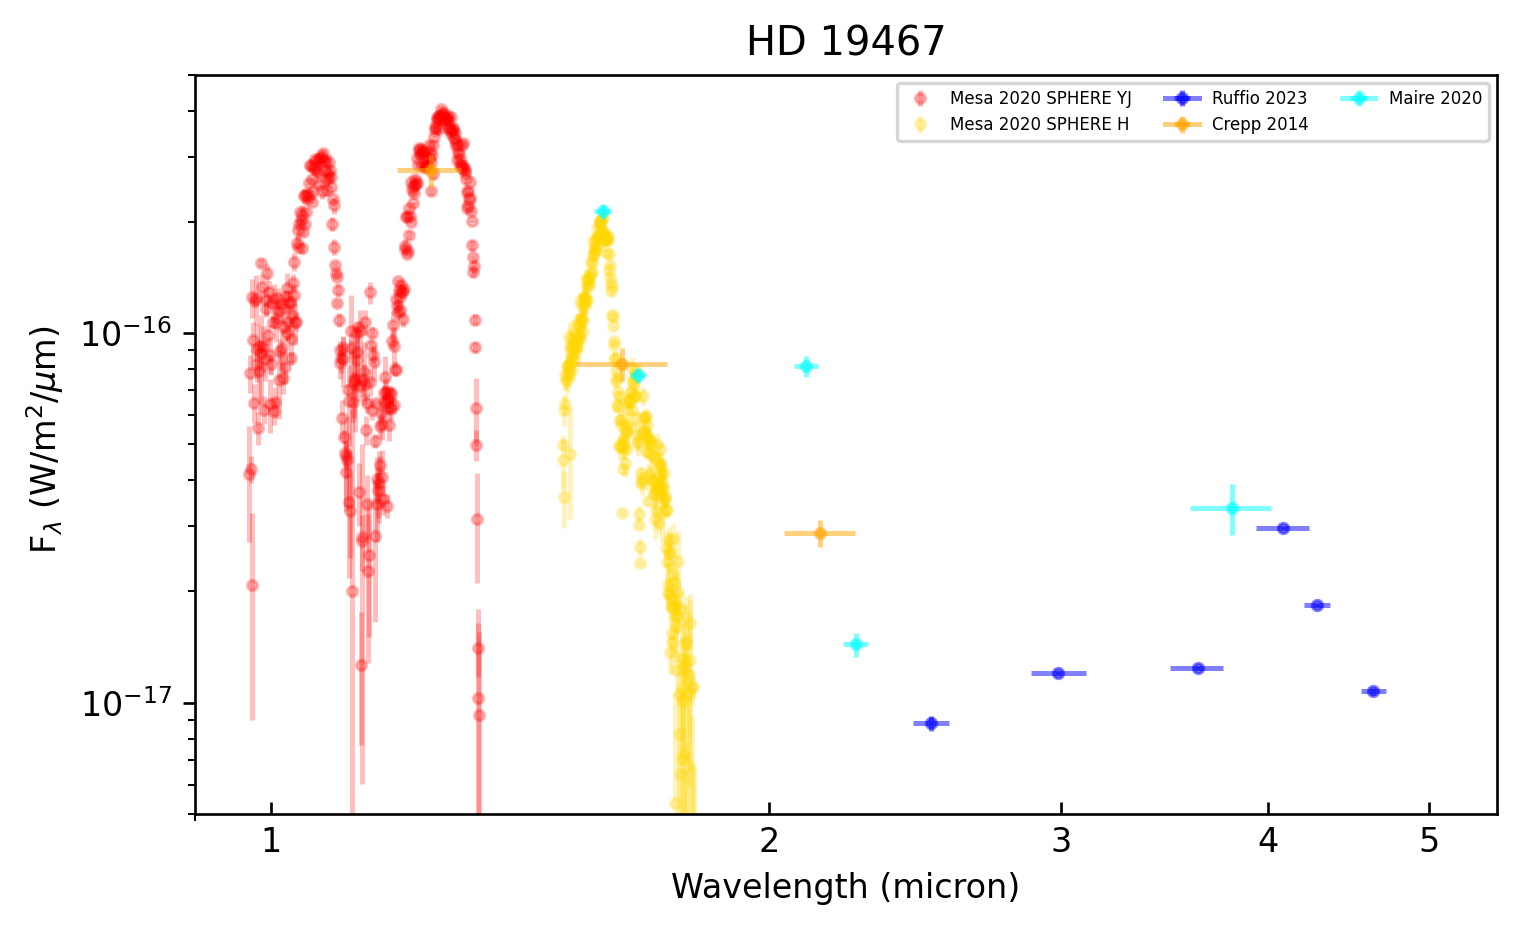

In [208]:
def synphot_2_xerr(synphot):
    '''transforms 1-sigma range of synphot transmission curve profile to x-error object for plotting photometric points'''
    wlr = synphot.wavel_range
    photw = np.linspace(wlr[0],wlr[1],10000)
    T = synphot.filter_interp(photw)
    sumT = np.cumsum(T)/np.sum(T)
    
    xl = photw[np.argmin(abs(sumT - 0.16))]
    xm = photw[np.argmin(abs(sumT - 0.5))]
    xr = photw[np.argmin(abs(sumT - 0.84))]
    xerr = np.array([xm-xl,xr-xm]).reshape(2,1)

    if False:
        plt.plot(photw,T)
        plt.plot(photw,sumT)
        plt.plot(xl,0.5,'k.')
        plt.plot(xm,0.5,'k.')
        plt.plot(xr,0.5,'k.')
        plt.errorbar(xm,0.5,xerr =xerr)

    return xm, xerr

plt.figure(figsize=(7,4),dpi=240)

colors = ['red','gold']
colors2 = ['blue','orange','cyan']

target = 'HD 19467'
phot_refd = photometric_archive[target]
spec_refd = spectroscopic_archive[target]

ri = 0
for ref in spec_refd.keys():
    specd = spec_refd[ref]
    print('-',ref)
    for inst in specd.keys():
        print('--',inst)
        color = colors[ri]
        wave,flux,err = specd[inst]['wave'],specd[inst]['flux'],specd[inst]['err']
        plt.errorbar(wave,flux,yerr=err,label=ref+' '+inst,linestyle='none',marker='.',zorder=-1,alpha=0.25,color=color)
        ri += 1
        
for ri,ref in enumerate(phot_refd.keys()):
    photd = phot_refd[ref]
    print('-',ref)
    color = colors2[ri]
    for bi,band in enumerate(photd.keys()):
        print('--',band)
        synphot = SyntheticPhotometry(band)
        xm, xerr = synphot_2_xerr(synphot)
        flux, err = photd[band]['flux'],photd[band]['err']
        if bi == 0:
            label = ref
        else:
            label = None
        if flux==0:
            plt.errorbar(xm,err,xerr=xerr,marker='v',label=label,color=color,zorder=2,alpha=0.5)
        else:
            plt.errorbar(xm,flux,xerr=xerr,yerr=err,marker='.',label=label,color=color,zorder=2,alpha=0.5)

plt.tick_params(axis='x', direction='in')
plt.title(target)
plt.legend(fontsize=5,ncols=3)
plt.ylim(5e-18,5e-16)
plt.yscale('log')
plt.ylabel(r' F$_\lambda$ (W/m$^2$/$\mu$m)')

plt.xlim([.9,5.5])
plt.xscale('log')
plt.xticks([1,2,3,4,5],['1','2','3','4','5'])
plt.xlabel('Wavelength (micron)')
plt.show()

### Defining the custom likelihood function

The following function will be passed to the ```dynesty``` sampler to compute the likelihood of our data given a model with particular parameters. It first computes the model atmosphere flux at R=100 and R=2700 by sampling the precomputed ```broadRGI``` objects, which is then rescaled by (radius/distance)^2, stretched according to the radial velocity parameter, and high-pass filtered with the custom splines and ```breads.utils.filter_spec_with_spline```. Then, the covariance matrices computed in notebook #3 are used to compute the chi-squared for the continuum-subtracted NIRSpec spectra, while chi-squared for the photometry and SPHERE spectroscopy are added after (with no covariance being used.)

In [142]:
def log_likelihood(parameters):
    teff, logg, mh, co, logkzz, planet_radius, delta_radial_velocity = parameters

    flux2700 = bRGI2700([teff, logg, mh, co, logkzz])[0]
    flux100 = bRGI100([teff, logg, mh, co, logkzz])[0]
    planet_r2d2 = ((planet_radius*u.Rjup/distance)**2).to(u.dimensionless_unscaled).value
    flux2700_rescaled = flux2700*planet_r2d2
    flux100_rescaled = flux100*planet_r2d2

    radial_velocity = best_RV + delta_radial_velocity
    rv_wave = wave*(1 + radial_velocity/const.c.value)
    downsample_RVshift_flux2700_rescaled = np.interp(rv_wave,bRGI2700.wavelength,flux2700_rescaled) 
    model_hpf, _ = filter_spec_with_spline(wave,downsample_RVshift_flux2700_rescaled,x_nodes=wv_nodes_dict['all'])
    v = (spec_hpf - model_hpf)[valid]
    covchi2 = np.linalg.multi_dot([v.T,Cinv,v])

    #compute chi2 on photom
    chi2_photom = 0
    for ref_key in photrefd.keys():
        photometric_points = photrefd[ref_key]
        for filter_key in photometric_points.keys():
            flux_err_dict = photometric_points[filter_key]
            flux,err = flux_err_dict['flux'],flux_err_dict['err']
            synphot = synphots[filter_key]
            band_flux, band_err = synphot.spectrum_to_flux(bRGI100.wavelength,flux100_rescaled) 
            chi2_band = ((flux - band_flux)/(err))**2
            chi2_photom += chi2_band
    
    #compute chi2 on spec
    chi2_spec = 0
    for ref_key in specrefd.keys():
        spectroscopic_data = specrefd[ref_key]
        for spec_key in spectroscopic_data.keys():
            wfe_dict = spectroscopic_data[spec_key]
            w,f,e = wfe_dict['wave'],wfe_dict['flux'],wfe_dict['err']
            flux100_rescaled_downsample = np.interp(w,bRGI100.wavelength,flux100_rescaled)
            chi2 = np.sum(((f - flux100_rescaled_downsample)/(e))**2)
            chi2_spec += chi2
    
    total_chi2 = covchi2 + chi2_photom + chi2_spec
    log_likelihood = -1/2.*total_chi2

    return log_likelihood

### Running the Sampler

Before the sampler can be started, the likelihood function above requires a few key variables to be defined on a per-target basis. The Photometric and Spectroscopic data dictionaries are sliced and used to instantiate the ```species.phot.syn_phot.SyntheticPhotometry``` objects which will be computing the flux integrals for the photometry (this step is slow and much more performant to do it once at the beginning than in every iteration). Then the NIRSpec spectra is loaded from the data product dictionary and filtered again for good measure. Additionally, the other target specific values are bound to variables ```distance```,```bRGI2700```,```bRGI100```, and ```best_RV``` for use in the likelihood function. Then, we define the priors to be uniform over a bounds of the atmosphere model, with additional uniform bounds for radius (0.2 to 2 Rjup) and deltaRV (-15 to 15 km/s). Lastly, the sampler is called with 1000 live points using the 'rwalk' keyword to reach a dlogz=0.1.

In [217]:
for target in target_list:
    print(target)

    #load data
    photrefd = photometric_archive[target[:-2]]
    specrefd = spectroscopic_archive[target[:-2]]
    print('spectra: {}'.format(list(specrefd.keys())))
    print('photometry: {}'.format(list(photrefd.keys())))

    #create synphots
    synphots = {}
    for ref_key in photrefd.keys():
        photometric_points = photrefd[ref_key]
        for filter_key in photometric_points.keys():
            synphot = SyntheticPhotometry(filter_key)
            synphots[filter_key] = synphot
    
    wse_dict = np.load(base_path+'products/{}.npy'.format(target),allow_pickle=True).item()
    wave,spec,err,Cinv,valid = wse_dict['wave'],wse_dict['spec'],wse_dict['err'],wse_dict['Cinv'],wse_dict['valid']
    spec_hpf,_ = filter_spec_with_spline(wave,spec,x_nodes=wv_nodes_dict['all'])

    distance = system_distances_pc[target[:-2]]*u.pc
    bRGI2700 = bRGI_dict2700[target]
    bRGI100 = bRGI_dict100[target]
    best_RV = best_RVs[target]
    print('best RV: {}'.format(best_RV))
    
    param_list = list(bRGI2700.points.values())
    shape = tuple([len(l) for l in param_list])
    npoints = np.prod(shape)
    param_outer_product = np.array(np.meshgrid(*[list(l) for l in param_list])).T.reshape(npoints,len(shape))

    #define prior
    #inherit params
    uppers = []
    lowers = []
    for i in range(5):
        p_i = param_list[i]
        uppers.append(p_i[-1])
        lowers.append(p_i[0])

    #radius (Rjup)
    uppers.append(2)
    lowers.append(0.5)
    
    #dRV (m/s)
    uppers.append(15*1e3)
    lowers.append(-15*1e3)

    uppers = np.array(uppers)
    lowers = np.array(lowers)

    def prior(p):
        x = ((uppers-lowers)*p + lowers) #flat prior for all parameters
        return x

    sampler = dynesty.NestedSampler(log_likelihood, prior, 7, nlive=1000, pool=Pool() ,queue_size=os.cpu_count(), sample='rwalk')
    savefname = base_path+'samples/{}-all_datasets'.format(target)
    sampler.run_nested(dlogz=0.1,checkpoint_file=savefname+'.save')
    results = sampler.results
    np.save(savefname+'-results.npy',results)

HD 19467 J
spectra: ['Mesa 2020']
photometry: ['Ruffio 2023', 'Crepp 2014', 'Maire 2020']
best RV: 2000.0


46661it [1:41:47,  7.64it/s, +1000 | bound: 270 | nc: 1 | ncall: 1234174 | eff(%):  3.865 | loglstar:   -inf < -40799.520 <    inf | logz: -40843.850 +/-  0.204 | dlogz:  0.000 >  0.100]


### Plotting Posterior Distributions

The following cell loads the sampler results and uses ```breads.utils.get_err_from_posterior``` to compute posterior ranges on the distribution of samples and plots them in histograms.

HD 19467


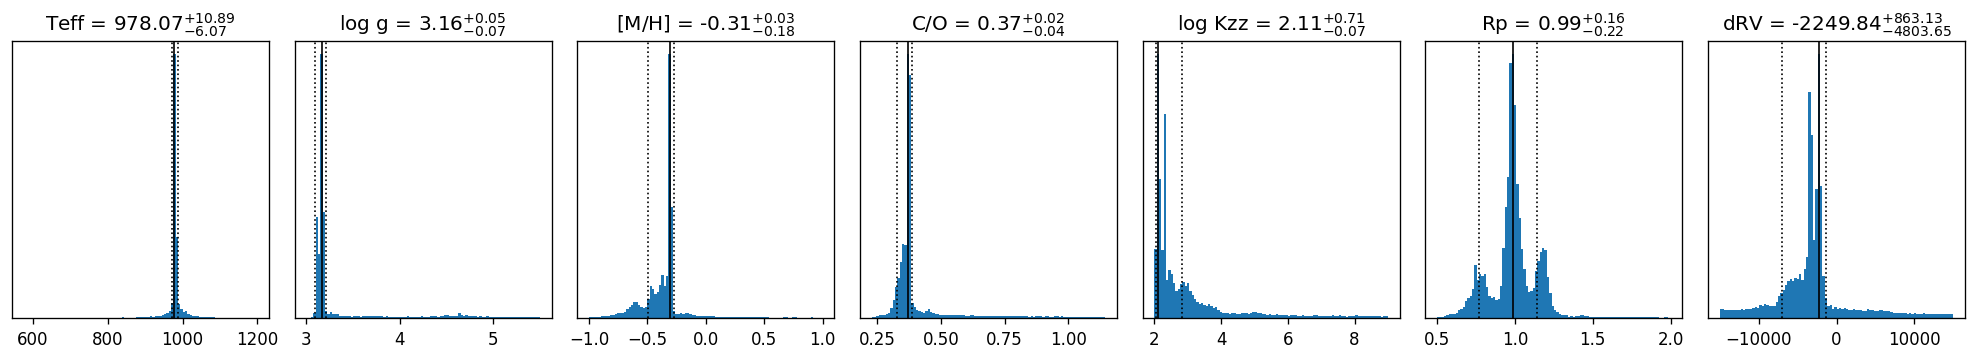

In [219]:
fig,ax = plt.subplots(1,7,figsize=(21,3),dpi=120,)
labels = ['Teff','log g','[M/H]','C/O','log Kzz','Rp','dRV']
posteriors = {}
for i,target in enumerate(target_list):
    print(target[:-2])
    savefname = base_path+'samples/{}-all_datasets'.format(target)
    results = np.load(savefname+'-results.npy',allow_pickle=True).item()
    post = []
    
    for j in range(7):
        y,x,_ = ax[j].hist(results.samples[:,j],bins=100)        
        cx,mx,px = get_err_from_posterior((x[1:]+x[:-1])/2,y)
        post.append([cx,px,mx])

        ax[j].set_title(r'{} = {}'.format(labels[j],np.round(cx,2))+r'$^{+'+str(np.round(px,2))+r'}_{-'+str(np.round(mx,2))+r'}$')
        ax[j].set_yticks([])
        ax[j].axvline(x=cx,linewidth=1,linestyle='-',color='k')
        ax[j].axvline(x=cx+px,linewidth=1,linestyle=':',color='k')
        ax[j].axvline(x=cx-mx,linewidth=1,linestyle=':',color='k')
        
    posteriors[target] = post

plt.subplots_adjust(wspace=0.1)
plt.show()

In [220]:
posteriors

{'HD 19467 J': [[978.0721786550769, 10.893951789162998, 6.0689530022066265],
  [3.1626939517956716, 0.04687290781591136, 0.06837396887239544],
  [-0.31036945261103355, 0.03472901652126975, 0.18109647970880027],
  [0.37097643914964606, 0.01716204237484481, 0.04178919282643684],
  [2.105080745734343, 0.709426827646118, 0.06999419139910446],
  [0.987725280870732, 0.1555715603580745, 0.21678629630781088],
  [-2249.8375188601367, 863.1325642697016, 4803.649145018281]]}

### Plotting the best fit model

The final cell in the notebook combines everything we have done previously, to plot the best fit model and the data together into one visualization.

- Mesa 2020
-- SPHERE YJ
-- SPHERE H
- Ruffio 2023
-- JWST/NIRCam.F250M
-- JWST/NIRCam.F300M
-- JWST/NIRCam.F360M
-- JWST/NIRCam.F410M
-- JWST/NIRCam.F430M
-- JWST/NIRCam.F460M
- Crepp 2014
-- Keck/NIRC2.J
-- Keck/NIRC2.H
-- Keck/NIRC2.Ks
- Maire 2020
-- Paranal/SPHERE.IRDIS_D_H23_2
-- Paranal/SPHERE.IRDIS_D_H23_3
-- Paranal/SPHERE.IRDIS_D_K12_1
-- Paranal/SPHERE.IRDIS_D_K12_2
-- Paranal/NACO.Lp


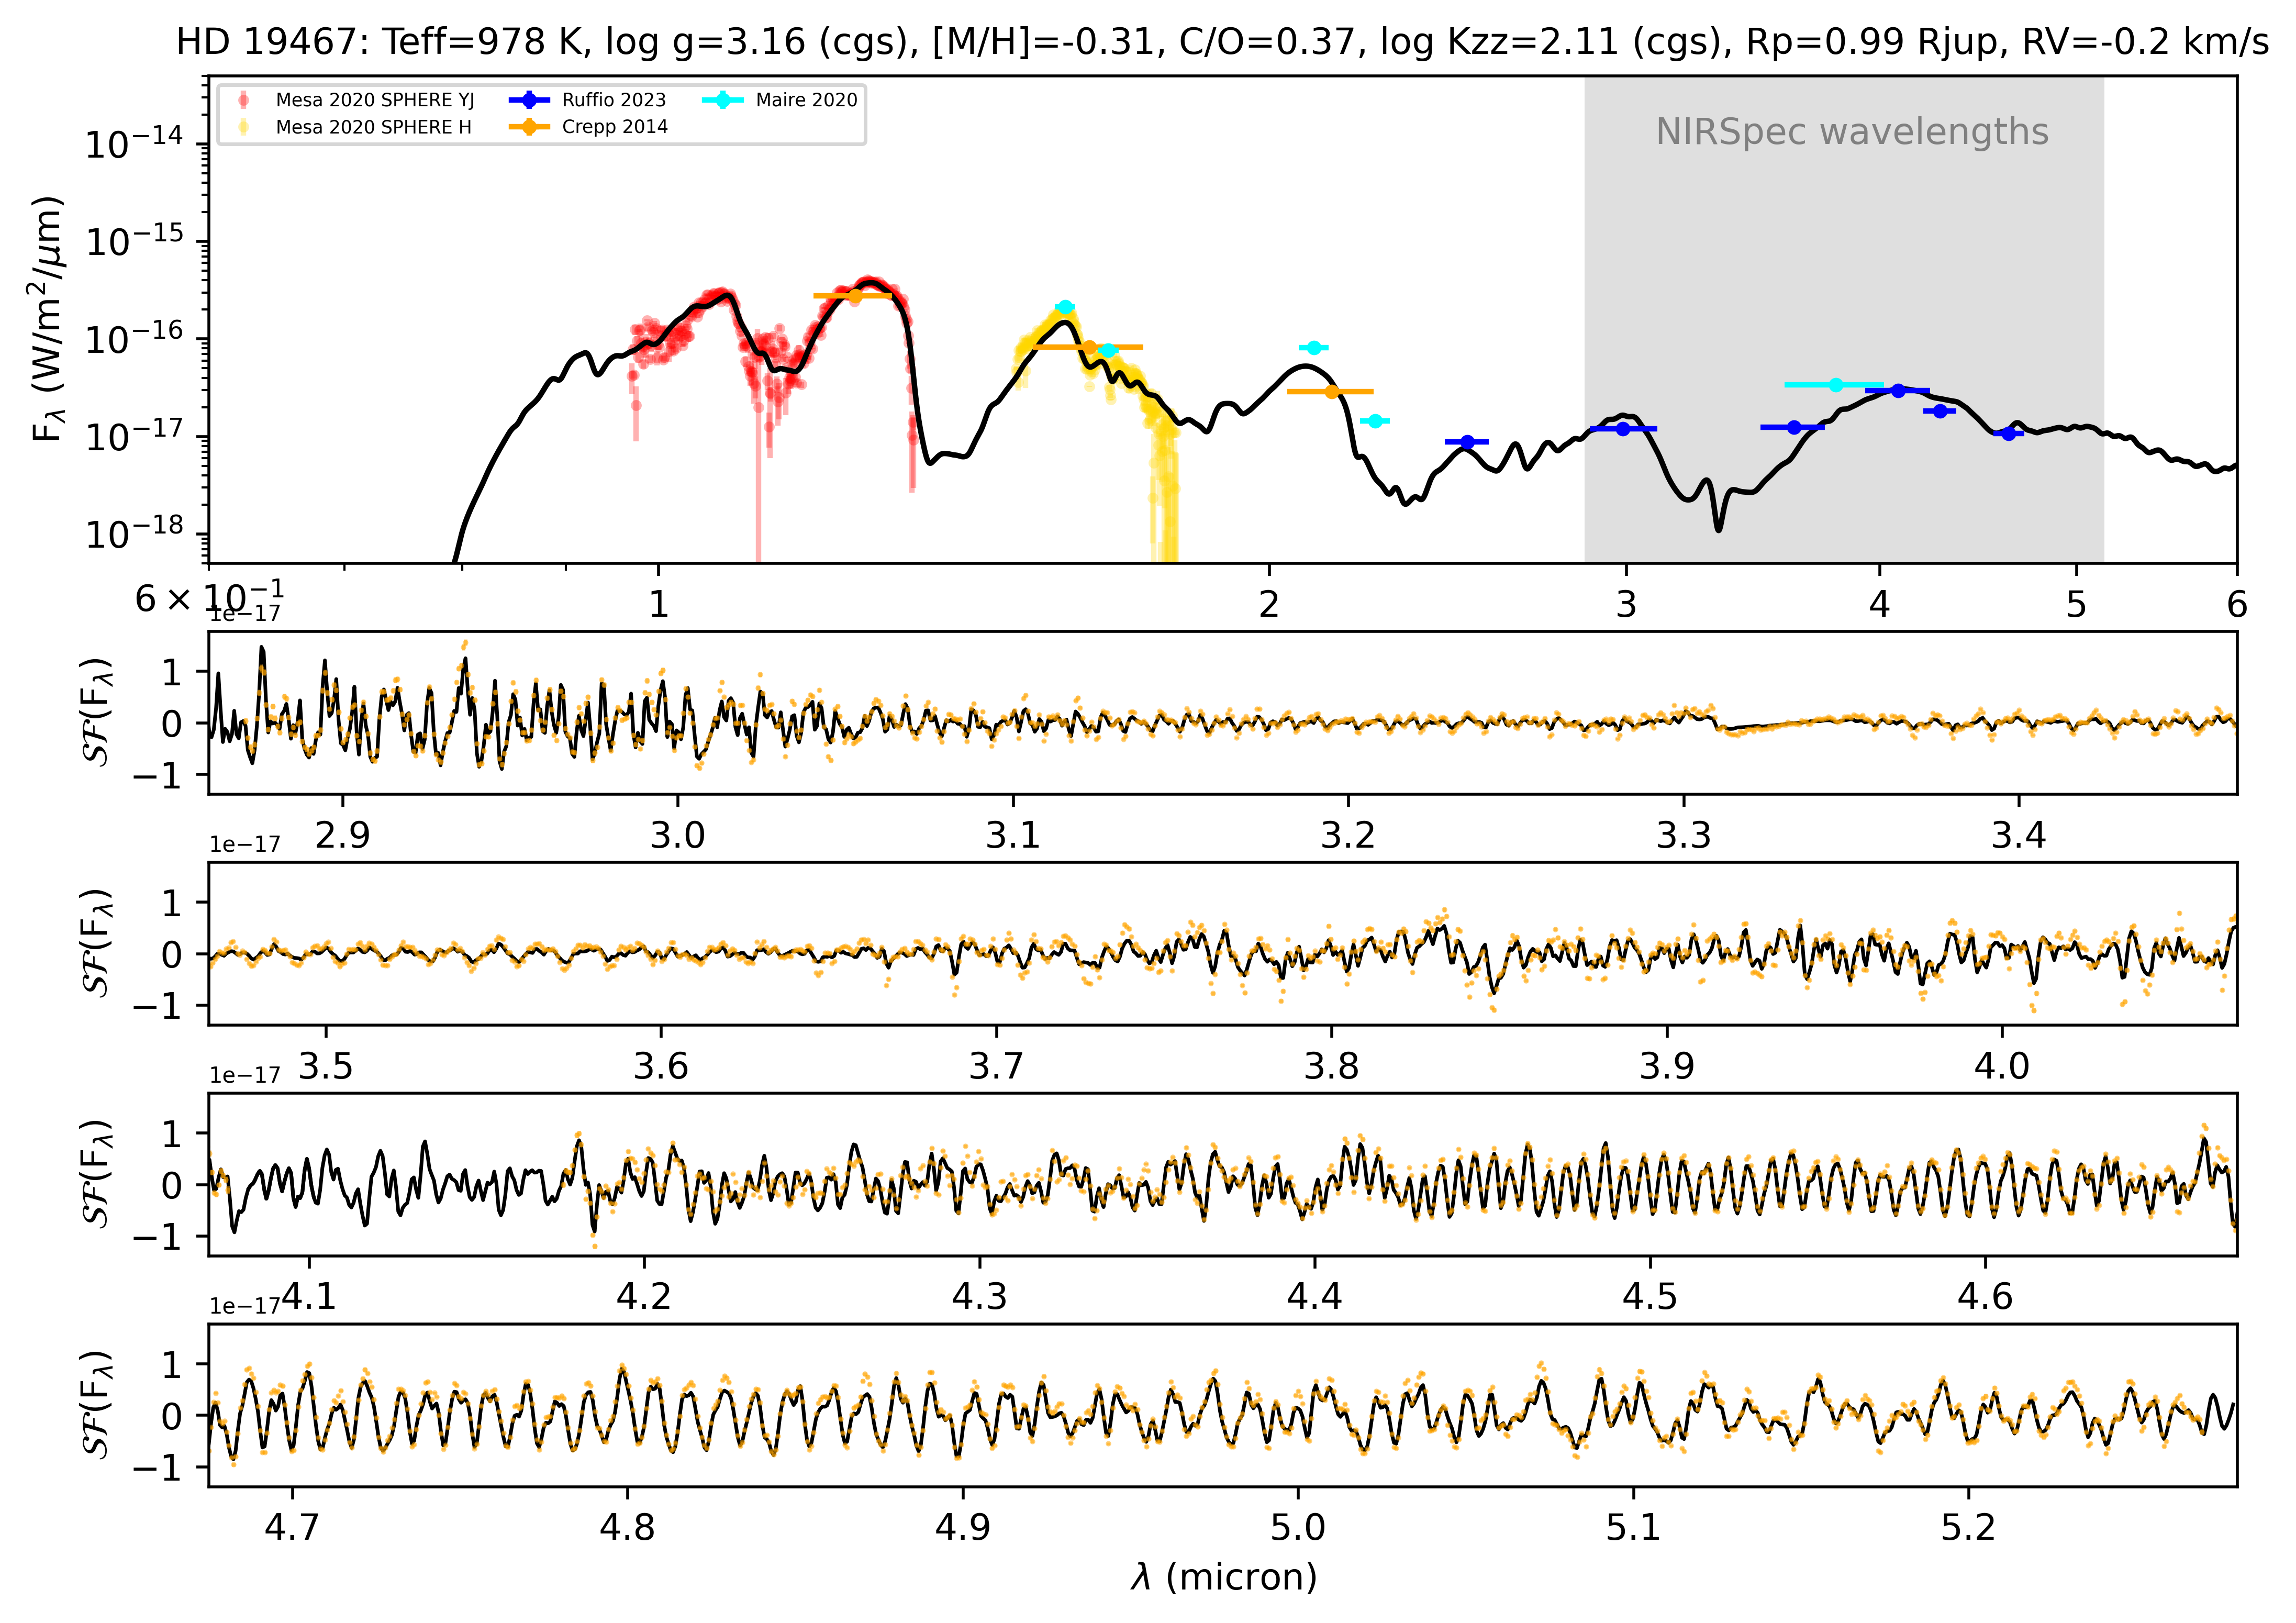

In [221]:
colors = ['orange']
colors1 = ['red','gold']
colors2 = ['blue','orange','cyan']
for colori,target in enumerate(target_list):
        
    fig, ax = plt.subplots(5,1,figsize=(10,7),dpi=500,gridspec_kw={'height_ratios':[3,1,1,1,1]})

    post = posteriors[target]
    teff_, logg_, mh_, co_, logkzz_, planet_radius_, delta_radial_velocity_, = post
    teff, logg, mh, co, logkzz, planet_radius, delta_radial_velocity = teff_[0], logg_[0], mh_[0], co_[0], logkzz_[0], planet_radius_[0], delta_radial_velocity_[0]
    
    best_RV = best_RVs[target]

    wse_dict = np.load(base_path+'products/{}.npy'.format(target),allow_pickle=True).item()
    wave,spec,err,Cinv,valid = wse_dict['wave'],wse_dict['spec'],wse_dict['err'],wse_dict['Cinv'],wse_dict['valid']
    spec_hpf,_ = filter_spec_with_spline(wave,spec,x_nodes=wv_nodes_dict['all'])

    distance = system_distances_pc[target[:-2]]*u.pc
    bRGI2700 = bRGI_dict2700[target]
    bRGI100 = bRGI_dict100[target]
    
    radial_velocity = best_RV + delta_radial_velocity
    rv_wave = wave*(1 + radial_velocity/const.c.value)

    flux2700 = bRGI2700([teff, logg, mh, co, logkzz])[0]
    flux100 = bRGI100([teff, logg, mh, co, logkzz])[0]
    planet_r2d2 = ((planet_radius*u.Rjup/distance)**2).to(u.dimensionless_unscaled).value

    flux100_rescaled = flux100*planet_r2d2
    flux2700_rescaled = np.interp(rv_wave,bRGI2700.wavelength,flux2700)*planet_r2d2
    hpf,_ = filter_spec_with_spline(wave,flux2700_rescaled,x_nodes=wv_nodes_dict['all'])
    
    for i in [1,2,3,4]:
        wind = np.where(np.diff(wave)<0)[0][0]+1
        l4, = ax[i].plot(wave[wind:],hpf[wind:],'k',alpha=1,linewidth=1)
        l4, = ax[i].plot(wave[:wind],hpf[:wind],'k',alpha=1,linewidth=1)
        l5 = ax[i].errorbar(wave,spec,err,color=colors[colori],linestyle='none',alpha=.5,marker='.',markersize=1,linewidth=1)
    ax[0].set_title(r'{}: Teff={} K, log g={} (cgs), [M/H]={}, C/O={}, log Kzz={} (cgs), Rp={} Rjup, RV={} km/s'.format(
        target[:-2], int(teff), np.round(logg,2), np.round(mh,2), np.round(co,2), np.round(logkzz,2), np.round(planet_radius,2), np.round(radial_velocity/1000,1)), fontsize=10)
    ax[0].plot(bRGI100.wavelength,flux100_rescaled,color='k')
    
    phot_refd = photometric_archive[target[:-2]]
    spec_refd = spectroscopic_archive[target[:-2]]
    ri = 0
    for ref in spec_refd.keys():
        specd = spec_refd[ref]
        print('-',ref)
        for inst in specd.keys():
            print('--',inst)
            color = colors1[ri]
            wave,flux,err = specd[inst]['wave'],specd[inst]['flux'],specd[inst]['err']
            ax[0].errorbar(wave,flux,yerr=err,label=ref+' '+inst,linestyle='none',marker='.',zorder=1,alpha=0.3,color=color,markeredgewidth=0)
            ri += 1
            
    for ri,ref in enumerate(phot_refd.keys()):
        photd = phot_refd[ref]
        print('-',ref)
        color = colors2[ri]
        for bi,band in enumerate(photd.keys()):
            print('--',band)
            synphot = SyntheticPhotometry(band)
            xm, xerr = synphot_2_xerr(synphot)
            flux, err = photd[band]['flux'],photd[band]['err']
            if bi == 0:
                label = ref
            else:
                label = None
            if flux==0:
                ax[0].errorbar(xm,err,xerr=xerr,marker='v',label=label,color=color)
            else:
                ax[0].errorbar(xm,flux,xerr=xerr,yerr=err,marker='.',label=label,color=color)

    ax[0].legend(fontsize=5,ncols=3)
    
    ax[0].set_yscale('log')
    ax[0].set_xscale('log')
    ax[0].set_xlim([0.6,6])
    ax[0].set_ylim([5e-19,5e-14])
    ax[0].set_xticks([1,2,3,4,5,6])
    ax[0].set_xticklabels(['1','2','3','4','5','6'])
    
    dw = 0.605
    ax[1].set_xlim([2.86,dw+2.86])
    ax[2].set_xlim([1*dw+2.86,2*dw+2.86])
    ax[3].set_xlim([2*dw+2.86,3*dw+2.86])
    ax[4].set_xlim([3*dw+2.86,4*dw+2.86])
    
    ax[0].set_ylabel(r'F$_\lambda$ (W/m$^2$/$\mu$m)')
    ax[1].set_ylabel(r'$\mathcal{SF}$(F$_\lambda$)')
    ax[2].set_ylabel(r'$\mathcal{SF}$(F$_\lambda$)')
    ax[3].set_ylabel(r'$\mathcal{SF}$(F$_\lambda$)')
    ax[4].set_ylabel(r'$\mathcal{SF}$(F$_\lambda$)')
    
    for i in [1,2,3,4]:
        ax[i].yaxis.get_offset_text().set_fontsize(6)
    
    ax[4].set_xlabel(r'$\lambda$ (micron)')
    
    import matplotlib.patches as patches
    rect = patches.Rectangle((2.86, 5e-19), 5.16-2.86, 5e-14, linewidth=1, edgecolor='none', facecolor='grey',alpha=0.25)
    ax[0].add_patch(rect)
    ax[0].text(3.1,1e-14,'NIRSpec wavelengths',color='grey')
    
    plt.subplots_adjust(hspace=0.3)
    plt.show()
